# CC4 — Modelos de Regressão (tendências entre variáveis)

**Projeto:** FlowCarreiras — métricas de perfil
**Base:** `dados/perfil_features.csv` (400 perfis simulados)

Objetivo (CC4): usar **regressão simples** como ferramenta de **representação de
tendências**, com **gráficos de dispersão, linha de tendência e análise de resíduos**,
explicando visualmente a relação entre os atributos do perfil e o engajamento recebido
(`curtidas_recebidas`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 90
ROXO = '#7c3aed'

df = pd.read_csv('dados/perfil_features.csv')
alvo = 'curtidas_recebidas'
print('Perfis:', len(df))
df[[alvo, 'n_obras_publicadas', 'seguidores', 'percentual_completude']].describe().round(1)

Perfis: 400


,curtidas_recebidas,n_obras_publicadas,seguidores,percentual_completude
count,400.0,400.0,400.0,400.0
mean,17.0,2.7,4.8,80.2
std,23.0,2.5,3.7,15.8
min,0.0,0.0,0.0,20.0
25%,0.0,0.0,2.0,70.0
50%,6.0,2.0,4.0,85.0
75%,28.0,4.0,8.0,90.0
max,110.0,11.0,16.0,100.0


## 1. Relações bivariadas: dispersão + linha de tendência

Cada ponto é um perfil. A reta (com intervalo de confiança) resume a tendência.

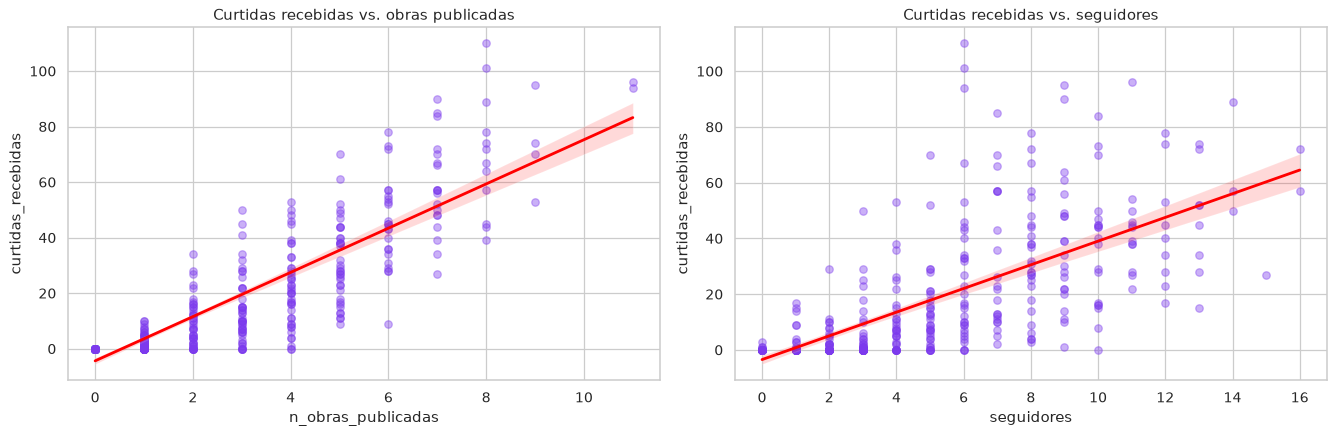

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(data=df, x='n_obras_publicadas', y=alvo, ax=axes[0],
            scatter_kws={'alpha': 0.4, 'color': ROXO}, line_kws={'color': 'red'})
axes[0].set_title('Curtidas recebidas vs. obras publicadas')
sns.regplot(data=df, x='seguidores', y=alvo, ax=axes[1],
            scatter_kws={'alpha': 0.4, 'color': ROXO}, line_kws={'color': 'red'})
axes[1].set_title('Curtidas recebidas vs. seguidores')
plt.tight_layout()
plt.show()

**Interpretação.** Ambas as relações são **positivas e fortes**: quanto mais o artista
**publica** e quanto maior sua **rede de seguidores**, mais curtidas recebe. A nuvem de pontos
**abre em leque** à medida que x cresce (a dispersão das curtidas aumenta para quem publica
muito) — um indício de **heterocedasticidade** que a análise de resíduos vai confirmar e que
motiva a transformação logarítmica.

## 2. Regressão linear simples

Modelo com um único preditor (`n_obras_publicadas`), na escala original.

Coeficiente: 7.96 curtidas por obra publicada
Intercepto:  -4.35
R²:          0.752


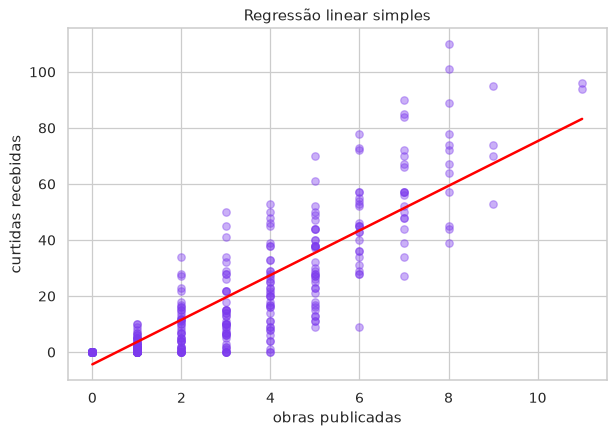

In [3]:
X1 = df[['n_obras_publicadas']].values
y = df[alvo].values
reg1 = LinearRegression().fit(X1, y)
pred1 = reg1.predict(X1)
print(f'Coeficiente: {reg1.coef_[0]:.2f} curtidas por obra publicada')
print(f'Intercepto:  {reg1.intercept_:.2f}')
print(f'R²:          {r2_score(y, pred1):.3f}')

plt.figure(figsize=(7, 5))
plt.scatter(df['n_obras_publicadas'], y, alpha=0.4, color=ROXO)
ordem = np.argsort(df['n_obras_publicadas'].values)
plt.plot(df['n_obras_publicadas'].values[ordem], pred1[ordem], color='red', lw=2)
plt.xlabel('obras publicadas'); plt.ylabel('curtidas recebidas')
plt.title('Regressão linear simples')
plt.tight_layout(); plt.show()

**Interpretação.** O coeficiente quantifica a tendência: cada obra publicada está associada,
em média, a um aumento de ~N curtidas (valor impresso acima). O R² mostra quanto da variação
das curtidas é explicado só por esse preditor — já é alto, confirmando que **produção é o
principal motor do engajamento**.

## 3. Regressão linear múltipla (escala log)

Como as contagens são assimétricas e a dispersão cresce com x, modelamos **`log1p`** do alvo
e dos preditores de contagem — o que lineariza a relação e estabiliza a variância.

In [4]:
feats = ['n_obras_publicadas', 'seguidores', 'comentarios_recebidos',
         'n_tags_expertise', 'percentual_completude', 'idade_conta_dias']
X = df[feats].copy()
for c in ['n_obras_publicadas', 'seguidores', 'comentarios_recebidos']:
    X[c] = np.log1p(X[c])
y_log = np.log1p(df[alvo].values)

Xtr, Xte, ytr, yte = train_test_split(X, y_log, test_size=0.25, random_state=42)
reg = LinearRegression().fit(Xtr, ytr)
pred_te = reg.predict(Xte)

print(f'R² (treino): {reg.score(Xtr, ytr):.3f}')
print(f'R² (teste):  {r2_score(yte, pred_te):.3f}')
print(f'RMSE (teste, escala log): {mean_squared_error(yte, pred_te) ** 0.5:.3f}')
print(f'MAE  (teste, escala log): {mean_absolute_error(yte, pred_te):.3f}')

coefs = pd.Series(reg.coef_, index=feats).sort_values(key=abs, ascending=False)
coefs.round(3).to_frame('coeficiente')

R² (treino): 0.847
R² (teste):  0.848
RMSE (teste, escala log): 0.619
MAE  (teste, escala log): 0.471


,coeficiente
n_obras_publicadas,1.398
seguidores,0.661
comentarios_recebidos,0.053
n_tags_expertise,0.034
percentual_completude,0.007
idade_conta_dias,-0.000


**Interpretação.** O modelo múltiplo explica a maior parte da variância do engajamento
(R² de teste impresso acima), e a proximidade entre R² de treino e teste indica **boa
generalização** (sem overfitting evidente). Os coeficientes ordenados por magnitude mostram
quais atributos mais puxam o engajamento — tipicamente **obras publicadas** e **seguidores** no
topo, com `percentual_completude` e `idade_conta_dias` contribuindo pouco, coerente com a EDA.

## 4. Análise de resíduos

Comparação dos resíduos do modelo na **escala original** (simples) vs. **escala log**
(múltiplo), seguida dos diagnósticos do modelo escolhido.

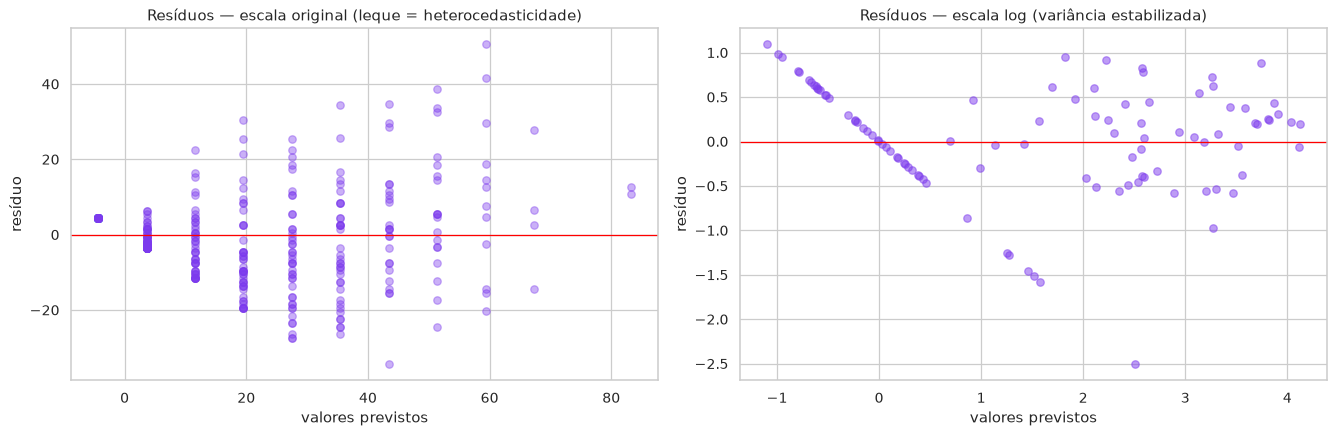

In [5]:
# Resíduos: escala original (modelo simples) vs. escala log (modelo múltiplo, no teste)
res_raw = y - pred1
res_log = yte - pred_te

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(pred1, res_raw, alpha=0.4, color=ROXO)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title('Resíduos — escala original (leque = heterocedasticidade)')
axes[0].set_xlabel('valores previstos'); axes[0].set_ylabel('resíduo')
axes[1].scatter(pred_te, res_log, alpha=0.5, color=ROXO)
axes[1].axhline(0, color='red', lw=1)
axes[1].set_title('Resíduos — escala log (variância estabilizada)')
axes[1].set_xlabel('valores previstos'); axes[1].set_ylabel('resíduo')
plt.tight_layout(); plt.show()

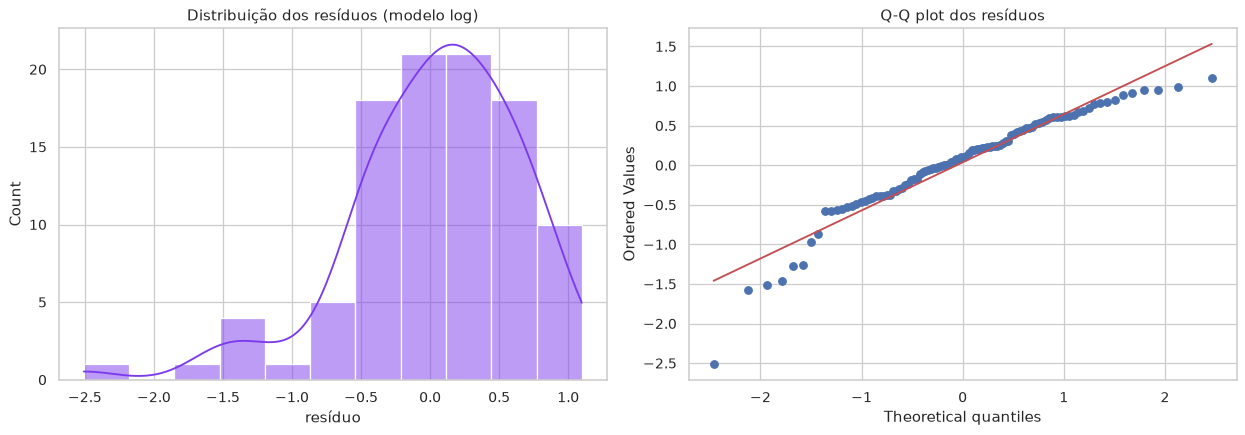

In [6]:
# Diagnósticos do modelo log: distribuição dos resíduos e Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(res_log, kde=True, ax=axes[0], color=ROXO)
axes[0].set_title('Distribuição dos resíduos (modelo log)')
axes[0].set_xlabel('resíduo')
stats.probplot(res_log, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot dos resíduos')
plt.tight_layout(); plt.show()

**Interpretação.** Na **escala original**, os resíduos formam um **leque** (variância cresce com
o valor previsto) — heterocedasticidade que viola os pressupostos da regressão linear. Na
**escala log**, os resíduos ficam **mais homogêneos** em torno de zero, sem padrão evidente: a
transformação cumpriu seu papel. O histograma e o **Q-Q plot** mostram resíduos
**aproximadamente normais** (pontos próximos da diagonal), com leves desvios nas caudas —
adequado para um modelo simples cujo objetivo é **representar a tendência**, não prever com
precisão cirúrgica.

## 5. Síntese

- A relação entre **produção/rede** e **engajamento** é forte e positiva — visível já na
  dispersão com linha de tendência.
- A regressão simples confirma a tendência (R² alto com um só preditor); o modelo múltiplo
  na **escala log** melhora o ajuste e **generaliza bem**.
- **Obras publicadas** e **seguidores** são os preditores dominantes; completude e antiguidade
  contribuem pouco — consistente com a EDA (CC3).
- A **análise de resíduos** evidenciou heterocedasticidade na escala original e a sua correção
  via `log1p`, com resíduos finais aproximadamente normais e sem padrão — validando o uso do
  modelo como ferramenta de leitura de tendências.